In [11]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from torch_geometric.utils import degree, to_networkx

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")



## Load Processed Synthetic Dataset

In [13]:
DATA_PATH = "../data/processed/synthetic_fraud.pt"
data = torch.load(DATA_PATH, weights_only=False)

print(data)
print("Nodes:", data.num_nodes)
print("Edges:", data.num_edges)
print("Node Features:", data.x.shape[1])
print("Edge Features:", data.edge_attr.shape[1])


Data(x=[5000, 12], edge_index=[2, 40900], edge_attr=[40900, 5], y=[5000])
Nodes: 5000
Edges: 40900
Node Features: 12
Edge Features: 5


## 1. Statistical Summary

In [14]:
feature_names = ['in_deg', 'out_deg', 'total_in', 'total_out', 
                 'avg_in', 'avg_out', 'night_in_ratio', 'night_out_ratio',
                 'noise_1', 'noise_2', 'noise_3', 'noise_4']

X = data.x.numpy()
y = data.y.numpy()

df_nodes = pd.DataFrame(X, columns=feature_names)
df_nodes["label"] = y

df_nodes.describe()


,in_deg,out_deg,total_in,total_out,avg_in,avg_out,night_in_ratio,night_out_ratio,noise_1,noise_2,noise_3,noise_4,label
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,8.180000,8.180000,779.705444,779.705383,81.876022,95.330185,0.369891,0.474148,0.009558,0.011643,0.006354,0.001443,0.098600
std,15.288778,2.827154,1605.185181,377.308777,52.217422,35.979256,0.302121,0.190403,0.996260,1.001053,0.998803,0.993226,0.298154
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3.344621,-3.536745,-4.841489,-3.470538,0.000000
25%,2.000000,6.000000,128.570572,513.190903,51.454503,72.350780,0.000000,0.333333,-0.658832,-0.656819,-0.656866,-0.684474,0.000000
50%,3.000000,8.000000,249.399033,723.248260,75.901798,89.657917,0.333333,0.500000,0.011925,0.025459,0.006307,0.004727,0.000000
75%,5.000000,10.000000,437.139404,999.609222,102.553329,111.584398,0.525647,0.600000,0.692223,0.688361,0.676377,0.672144,0.000000
max,76.000000,20.000000,10098.440430,4593.734375,927.892456,638.613892,1.000000,1.000000,3.970522,3.527218,3.672183,3.282605,1.000000


In [15]:
edge_features = data.edge_attr.numpy()

df_edges = pd.DataFrame(
    edge_features,
    columns=["log_amount", "time_norm", "channel_0", "channel_1", "channel_2"]
)

df_edges.describe()


,log_amount,time_norm,channel_0,channel_1,channel_2
count,40900.000000,40900.000000,40900.000000,40900.000000,40900.000000
mean,4.247489,0.469133,0.333447,0.334621,0.331932
std,0.794604,0.336612,0.471451,0.471864,0.470912
min,0.969776,0.000000,0.000000,0.000000,0.000000
25%,3.714327,0.130435,0.000000,0.000000,0.000000
50%,4.244083,0.434783,0.000000,0.000000,0.000000
75%,4.780592,0.782609,1.000000,1.000000,1.000000
max,8.229274,1.000000,1.000000,1.000000,1.000000


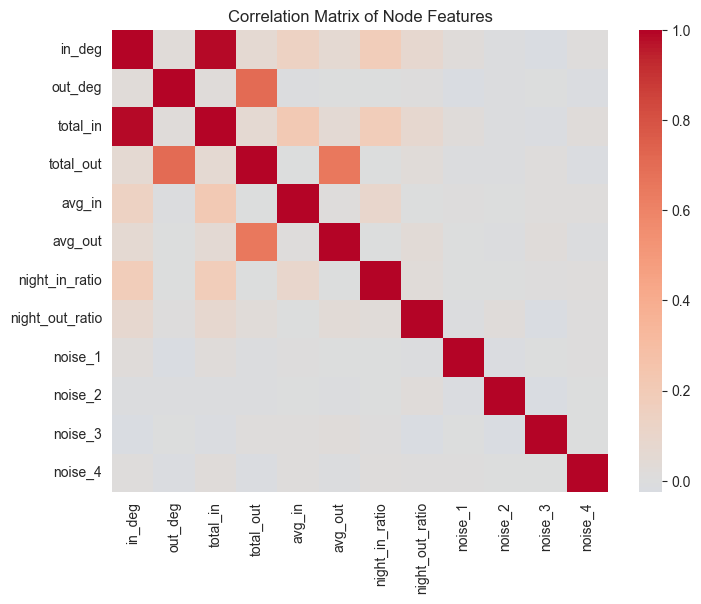

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df_nodes[feature_names].corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Node Features")
plt.show()


## 2. Graph Structure Analysis

In [17]:
src, dst = data.edge_index

in_deg = degree(dst, num_nodes=data.num_nodes).numpy()
out_deg = degree(src, num_nodes=data.num_nodes).numpy()

print("In-Degree Mean:", in_deg.mean())
print("Out-Degree Mean:", out_deg.mean())


In-Degree Mean: 8.18
Out-Degree Mean: 8.18


In [19]:
G = to_networkx(data, to_undirected=True)

components = list(nx.connected_components(G))
component_sizes = [len(c) for c in components]

print("Number of Connected Components:", len(components))
print("Largest Component Size:", max(component_sizes))


Number of Connected Components: 1
Largest Component Size: 5000


In [20]:
density = nx.density(G)

print("Graph Density:", density)
print("Graph Sparsity:", 1 - density)
print("Average Degree:", data.num_edges / data.num_nodes)


Graph Density: 0.0032580116023204642
Graph Sparsity: 0.9967419883976796
Average Degree: 8.18


## 3. Label Analysis

In [21]:
label_counts = df_nodes["label"].value_counts()
label_counts


label
0    4507
1     493
Name: count, dtype: int64

In [22]:
src_labels = y[src.numpy()]
dst_labels = y[dst.numpy()]

same_label_edges = (src_labels == dst_labels).sum()
homophily = same_label_edges / len(src_labels)

print("Edge Homophily:", homophily)

Edge Homophily: 0.31305623471882643


In [23]:
fraud_nodes = df_nodes[df_nodes["label"] == 1]
legit_nodes = df_nodes[df_nodes["label"] == 0]

comparison = pd.DataFrame({
    "Fraud Mean": fraud_nodes[feature_names].mean(),
    "Legit Mean": legit_nodes[feature_names].mean()
})

comparison

,Fraud Mean,Legit Mean
in_deg,53.574036,3.214555
out_deg,8.365111,8.159752
total_in,5488.692871,264.610962
total_out,847.276978,772.314148
avg_in,102.413391,79.629532
avg_out,101.609596,94.643303
night_in_ratio,0.534598,0.351874
night_out_ratio,0.517250,0.469433
noise_1,0.063578,0.003649
noise_2,-0.009693,0.013977


## 4. Visualization

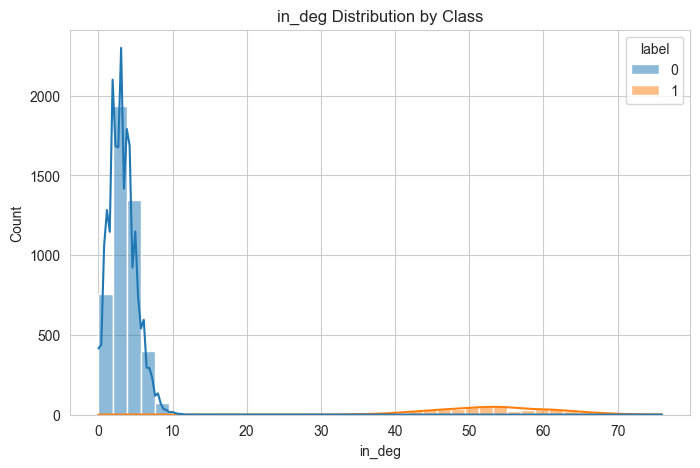

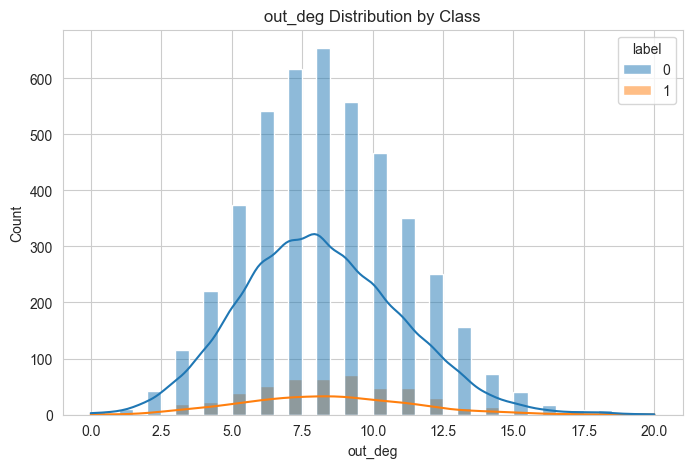

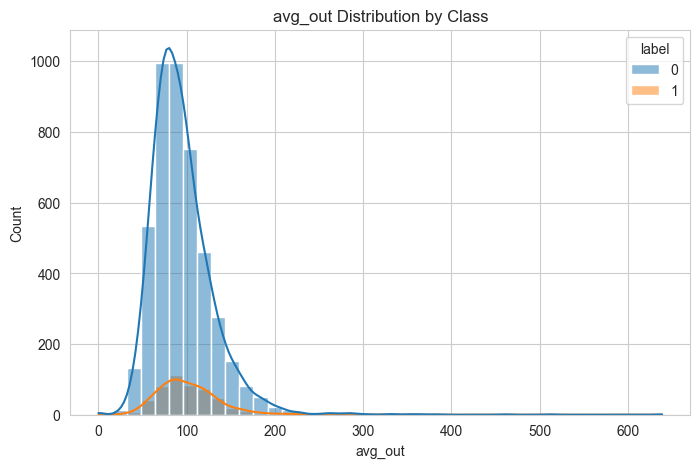

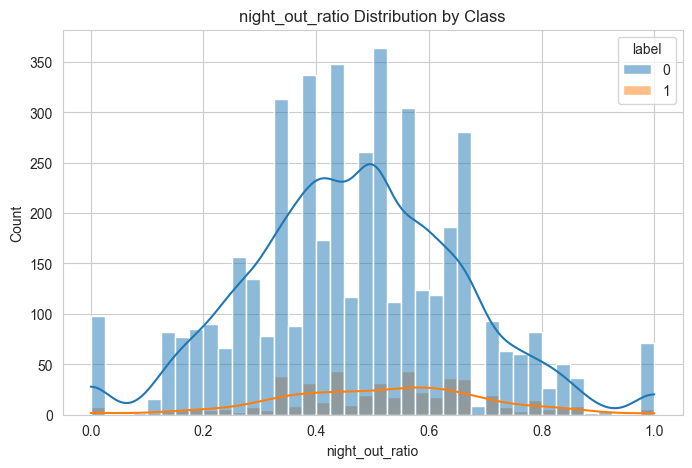

In [24]:
key_features = ['in_deg', 'out_deg', 'avg_out', 'night_out_ratio']

for feature in key_features:
    plt.figure()
    sns.histplot(df_nodes, x=feature, hue="label", bins=40, kde=True)
    plt.title(f"{feature} Distribution by Class")
    plt.show()

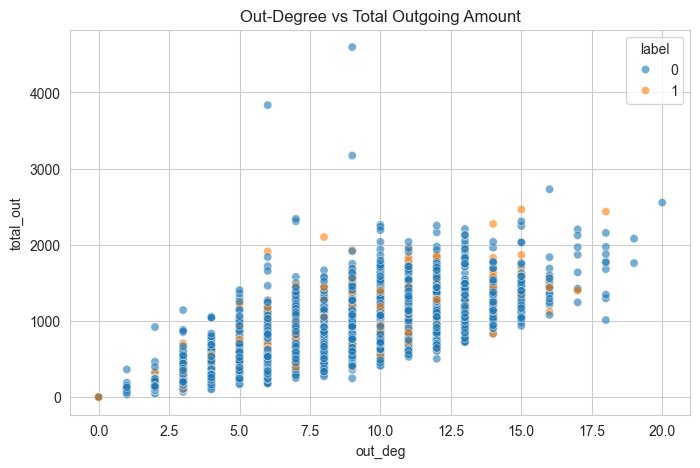

In [25]:
sns.scatterplot(
    data=df_nodes,
    x="out_deg",
    y="total_out",
    hue="label",
    alpha=0.6
)

plt.title("Out-Degree vs Total Outgoing Amount")
plt.show()


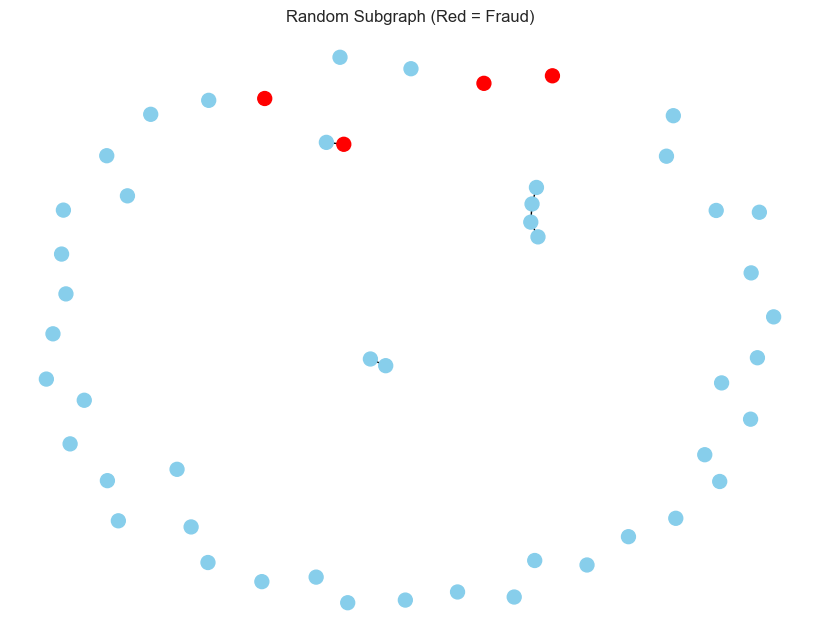

In [26]:
sample_nodes = np.random.choice(data.num_nodes, 50, replace=False)
subgraph = G.subgraph(sample_nodes)

pos = nx.spring_layout(subgraph, seed=42)

node_colors = [
    "red" if y[n] == 1 else "skyblue"
    for n in subgraph.nodes()
]

plt.figure(figsize=(8,6))
nx.draw(subgraph, pos, node_color=node_colors, node_size=100, with_labels=False)
plt.title("Random Subgraph (Red = Fraud)")
plt.show()
